# Figure 4A — how much of each knockout's effect a factor explains

Decomposes the significant effect-size matrix into 15 independent components,
then asks, for every knockout, how much of its effect profile each component
explains on its own and how much all fifteen explain together.

## Setup

In [1]:
library(ica)
library(pheatmap)
library(data.table)
library(repr)

computeR2 <- function(response, prediction) {
    rss <- sum((response - prediction)^2, na.rm = TRUE)
    tss <- sum((response - mean(response, na.rm = TRUE))^2)
    1 - rss / tss
}

save_pheatmap_pdf <- function(x, filename, width = 7, height = 7) {
    stopifnot(!missing(x), !missing(filename))
    pdf(filename, width = width, height = height)
    grid::grid.newpage(); grid::grid.draw(x$gtable); dev.off()
}

dir.create("figures", showWarnings = FALSE)
dir.create("outputs", showWarnings = FALSE)

In [2]:
E3LIGASE <- "/home/eraslab1/Projects/E3Ligase/analysisSingle"
SIGNIFICANT_COEFS <- file.path(E3LIGASE, "TextFiles/SignificantCoefMatrix.csv")
GUIDE_MODULES     <- file.path(E3LIGASE, "TextFiles/ME_GuideModules_leiden_6_Modules.csv")

N_FACTORS     <- 15      # independent components
RANDOM_SEED   <- 1       # icaimax is stochastic; see the note below
R2_THRESHOLD  <- 0.25    # knockouts shown in the figure
R2_LIMITS     <- c(0.05, 0.2)   # colour scale

annoCols <- list(
    GeneGroup = c(G0 = "#A6CEE3", G1 = "#1F78B4", G2 = "#B2DF8A", G3 = "#33A02C",
                  G4 = "#FB9A99", G5 = "#FDBF6F", G6 = "#FF7F00", G7 = "#CAB2D6",
                  G8 = "#6A3D9A", G9 = "#FFFF99", G10 = "#B5651D"),
    GuideGroup = c(M1 = "#aa40fc", M2 = "#1f77b4", M3 = "#ff7f0e",
                   M4 = "#8c564b", M5 = "#d62728", M6 = "#279e68")
)

## Effect sizes and guide modules

The coefficient matrix is transposed so that knockouts are columns; row names
are guide identifiers, of which only the gene name part is kept.

In [3]:
selCoefs <- t(read.csv(SIGNIFICANT_COEFS, row.names = 1))
colnames(selCoefs) <- sapply(colnames(selCoefs), function(x) strsplit(x, "_")[[1]][2])

guideModulesN <- data.frame(read.csv(GUIDE_MODULES), row.names = 1)
rownames(guideModulesN) <- guideModulesN$GuideName
guideModulesN$GuideGroup <- guideModulesN$NewGuideGroup   # modules are named M1..M6
guideModulesN$NewGuideGroup <- NULL
guideModulesN$GuideColor <- NULL

cat(nrow(selCoefs), "response genes x", ncol(selCoefs), "knockouts\n")

1041 response genes x 329 knockouts


## Independent components

:::{note}
`icaimax` is stochastic and the original notebook did not seed it. A seed is
set here so the decomposition is reproducible; the variance explained matched
the published values to 1e-14 either way.
:::

In [4]:
set.seed(RANDOM_SEED)
myH <- icaimax(selCoefs, nc = N_FACTORS, center = TRUE)$S
dim(myH)

[1] 1041   15

## Variance explained, per factor and by all of them

Each factor is regressed against each knockout's effect profile on its own;
the `ALL` row regresses every factor together, so it bounds the rest.

In [5]:
facR2Mat <- data.frame(matrix(0, nrow = N_FACTORS + 1, ncol = ncol(selCoefs)))
rownames(facR2Mat) <- c(paste0("Factor_", 1:N_FACTORS), "ALL")
colnames(facR2Mat) <- colnames(selCoefs)

for (fac in 1:ncol(myH)) {
    for (pert in 1:ncol(selCoefs)) {
        fit <- lm(y ~ x, data = data.frame(x = myH[, fac], y = selCoefs[, pert]))
        facR2Mat[paste0("Factor_", fac), colnames(selCoefs)[pert]] <-
            computeR2(selCoefs[, pert], predict(fit))
    }
}

allFactors <- copy(data.frame(myH))
for (pert in 1:ncol(selCoefs)) {
    allFactors$y <- selCoefs[, pert]
    fit <- lm(y ~ ., data = allFactors)
    facR2Mat["ALL", colnames(selCoefs)[pert]] <- computeR2(allFactors$y, predict(fit))
}

facR2Mat <- facR2Mat[, order(-facR2Mat["ALL", ])]     # best explained knockouts first
write.csv(facR2Mat, "outputs/ExplainedVariancePerFactor.csv")
facR2Mat["ALL", 1:8]

Warning message in xtfrm.data.frame(x):
“cannot xtfrm data frames”


,Keap1,Cul3,Chd4,Eif3i,Tceb2,Nf1,Mtor,Eif3f
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ALL,0.9604128,0.937673,0.9185589,0.8884156,0.871838,0.8695006,0.8591231,0.8543748


## Figure 4A — the best explained knockouts

203 knockouts explained above 0.25 


agg_record_1909893419 
                    2

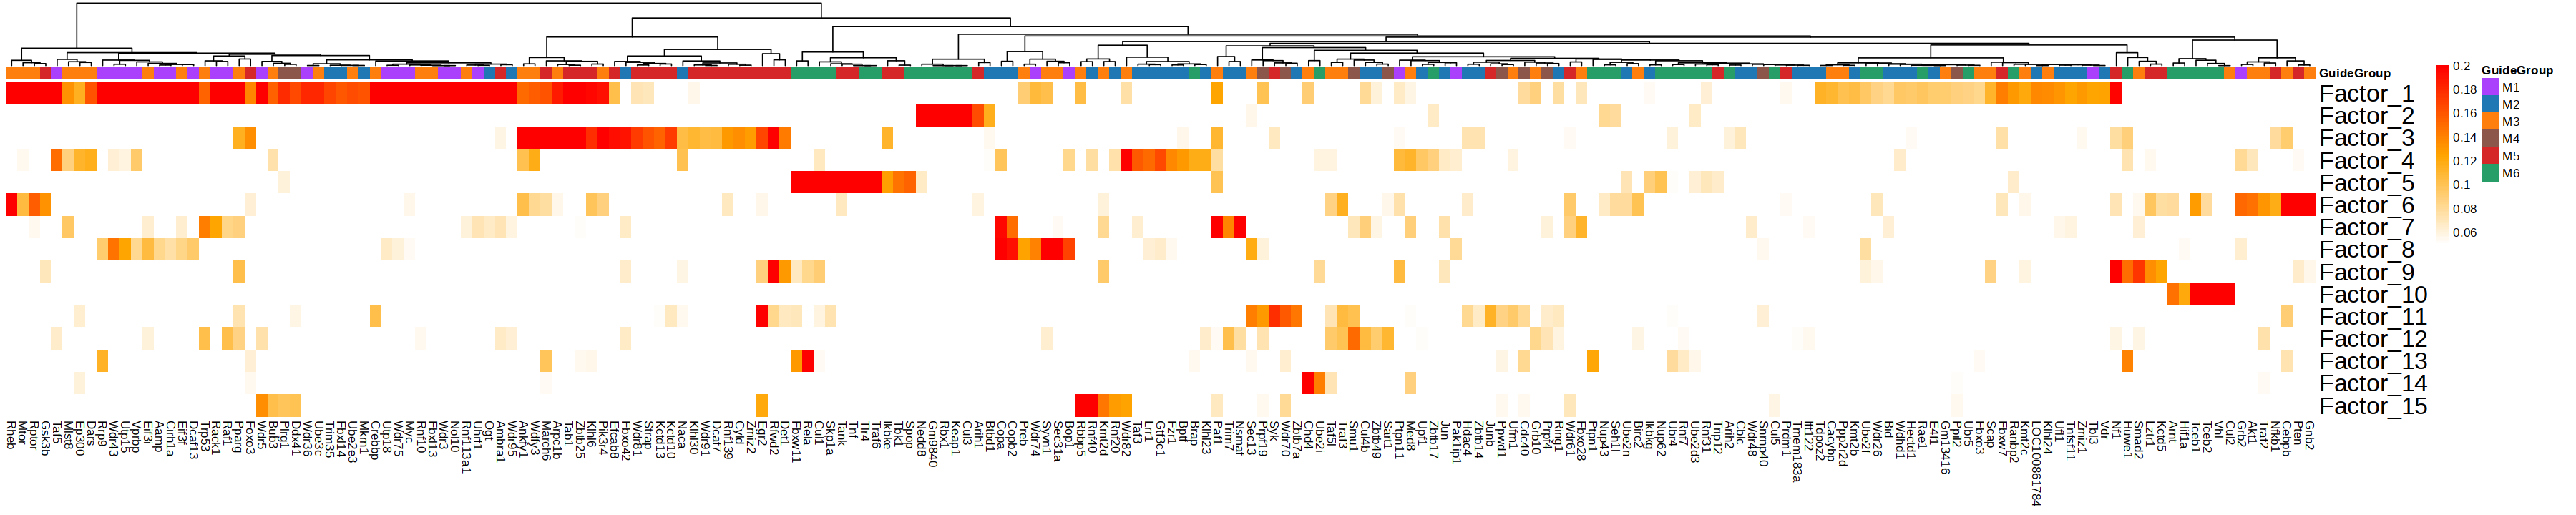

In [6]:
allExpVar <- unlist(facR2Mat["ALL", ])
highExp <- names(allExpVar[allExpVar > R2_THRESHOLD])
cat(length(highExp), "knockouts explained above", R2_THRESHOLD, "\n")

facR2MatPlot <- copy(facR2Mat[, highExp])
facR2MatPlot[facR2MatPlot > R2_LIMITS[2]] <- R2_LIMITS[2]
facR2MatPlot[facR2MatPlot < R2_LIMITS[1]] <- R2_LIMITS[1]

annotDFcol <- guideModulesN[colnames(facR2MatPlot), ]
annotDFcol$GuideName <- NULL

options(repr.plot.width = 30, repr.plot.height = 6)
xx <- pheatmap(facR2MatPlot[1:N_FACTORS, ],
               cluster_cols = TRUE, cluster_rows = FALSE,
               annotation_col = annotDFcol, annotation_colors = annoCols,
               clustering_method = "ward.D2", fontsize_row = 20,
               clustering_distance_rows = "euclidean",
               colorRampPalette(c("white", "orange", "red"))(100))

save_pheatmap_pdf(xx, "figures/Figure_4A.pdf", width = 28, height = 6)